In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= SOLO CAMBIA ESTO =========
FILE_PATH = "/content/Aletsch_serie_hectareas.csv"
# ====================================

BASELINE_START = 2000
BASELINE_END = 2009

# Nombre automático según el archivo
SITE_NAME = os.path.splitext(os.path.basename(FILE_PATH))[0]

# Carpeta de salida automática
OUTPUT_DIR = f"/content/{SITE_NAME}_graficos"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 150

In [ ]:
df = pd.read_csv(FILE_PATH)

# Validación mínima
required_cols = {"year", "snow_ha"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Limpieza
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["snow_ha"] = pd.to_numeric(df["snow_ha"], errors="coerce")
df = df.dropna(subset=["year", "snow_ha"]).sort_values("year").reset_index(drop=True)
df["year"] = df["year"].astype(int)

if df.empty:
    raise ValueError("El CSV no contiene datos válidos.")

# Línea base
baseline_mask = (df["year"] >= BASELINE_START) & (df["year"] <= BASELINE_END)
baseline_df = df.loc[baseline_mask]

if baseline_df.empty:
    raise ValueError(f"No hay datos entre {BASELINE_START} y {BASELINE_END} para la línea base.")

baseline_mean = baseline_df["snow_ha"].mean()

# Métricas derivadas
df["anomaly_ha"] = df["snow_ha"] - baseline_mean
df["anomaly_pct"] = (df["snow_ha"] / baseline_mean - 1) * 100
df["yoy_pct"] = df["snow_ha"].pct_change() * 100
df["below_baseline"] = df["snow_ha"] < baseline_mean
df["rolling_5y"] = df["snow_ha"].rolling(window=5, min_periods=1).mean()
df["deficit_ha"] = (baseline_mean - df["snow_ha"]).clip(lower=0)
df["cumulative_deficit_ha"] = df["deficit_ha"].cumsum()
df["decade"] = (df["year"] // 10) * 10

start_year = int(df["year"].min())
end_year = int(df["year"].max())
start_val = float(df.loc[df["year"] == start_year, "snow_ha"].iloc[0])
end_val = float(df.loc[df["year"] == end_year, "snow_ha"].iloc[0])
net_change_pct = ((end_val - start_val) / start_val) * 100 if start_val != 0 else np.nan

min_row = df.loc[df["snow_ha"].idxmin()]
max_row = df.loc[df["snow_ha"].idxmax()]

top5 = df.nlargest(5, "snow_ha").sort_values("snow_ha", ascending=True)
bottom5 = df.nsmallest(5, "snow_ha").sort_values("snow_ha", ascending=True)

print("Archivo:", FILE_PATH)
print("Zona:", SITE_NAME)
print("Salida:", OUTPUT_DIR)
print(df.head())

Archivo: /content/Aletsch_serie_hectareas.csv
Zona: Aletsch_serie_hectareas
Salida: /content/Aletsch_serie_hectareas_graficos
   year       snow_ha   anomaly_ha  anomaly_pct    yoy_pct  below_baseline  \
0  2000  21457.950430  -359.427904    -1.647439        NaN            True   
1  2001  22614.964218   797.585883     3.655737   5.392005           False   
2  2002  24048.082068  2230.703734    10.224435   6.337033           False   
3  2003  19152.598687 -2664.779647   -12.214023 -20.357064            True   
4  2004  22030.264510   212.886176     0.975764  15.024937           False   

     rolling_5y   deficit_ha  cumulative_deficit_ha  decade  
0  21457.950430   359.427904             359.427904    2000  
1  22036.457324     0.000000             359.427904    2000  
2  22706.998905     0.000000             359.427904    2000  
3  21818.398851  2664.779647            3024.207551    2000  
4  21860.771983     0.000000            3024.207551    2000  


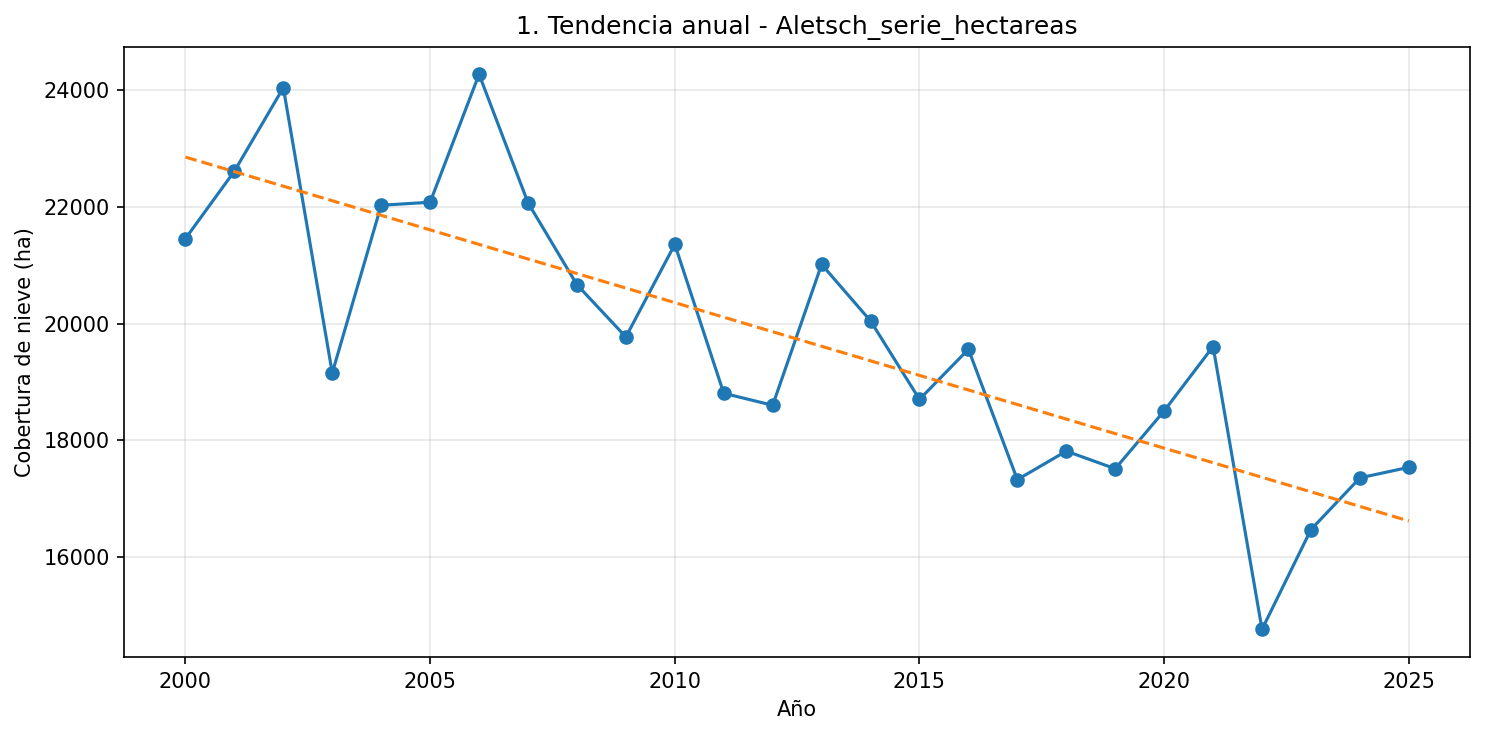

In [ ]:
plt.figure()
plt.plot(df["year"], df["snow_ha"], marker="o")

m, b = np.polyfit(df["year"], df["snow_ha"], 1)
plt.plot(df["year"], m * df["year"] + b, linestyle="--")

plt.title(f"1. Tendencia anual - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Cobertura de nieve (ha)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_tendencia_anual.png", bbox_inches="tight")
plt.show()

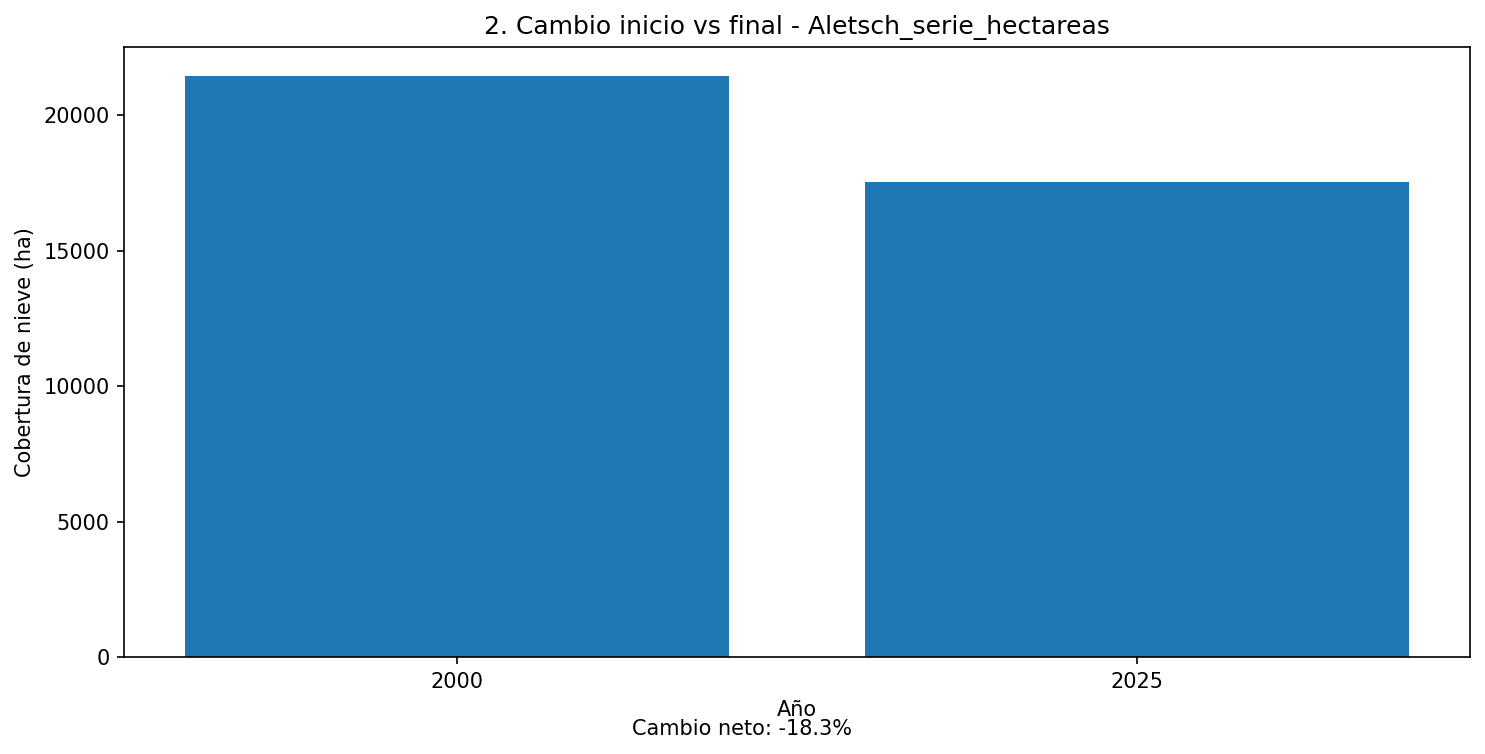

In [ ]:
plt.figure()
plt.bar([str(start_year), str(end_year)], [start_val, end_val])
plt.title(f"2. Cambio inicio vs final - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Cobertura de nieve (ha)")
plt.figtext(0.5, 0.01, f"Cambio neto: {net_change_pct:.1f}%", ha="center")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_cambio_inicio_vs_final.png", bbox_inches="tight")
plt.show()

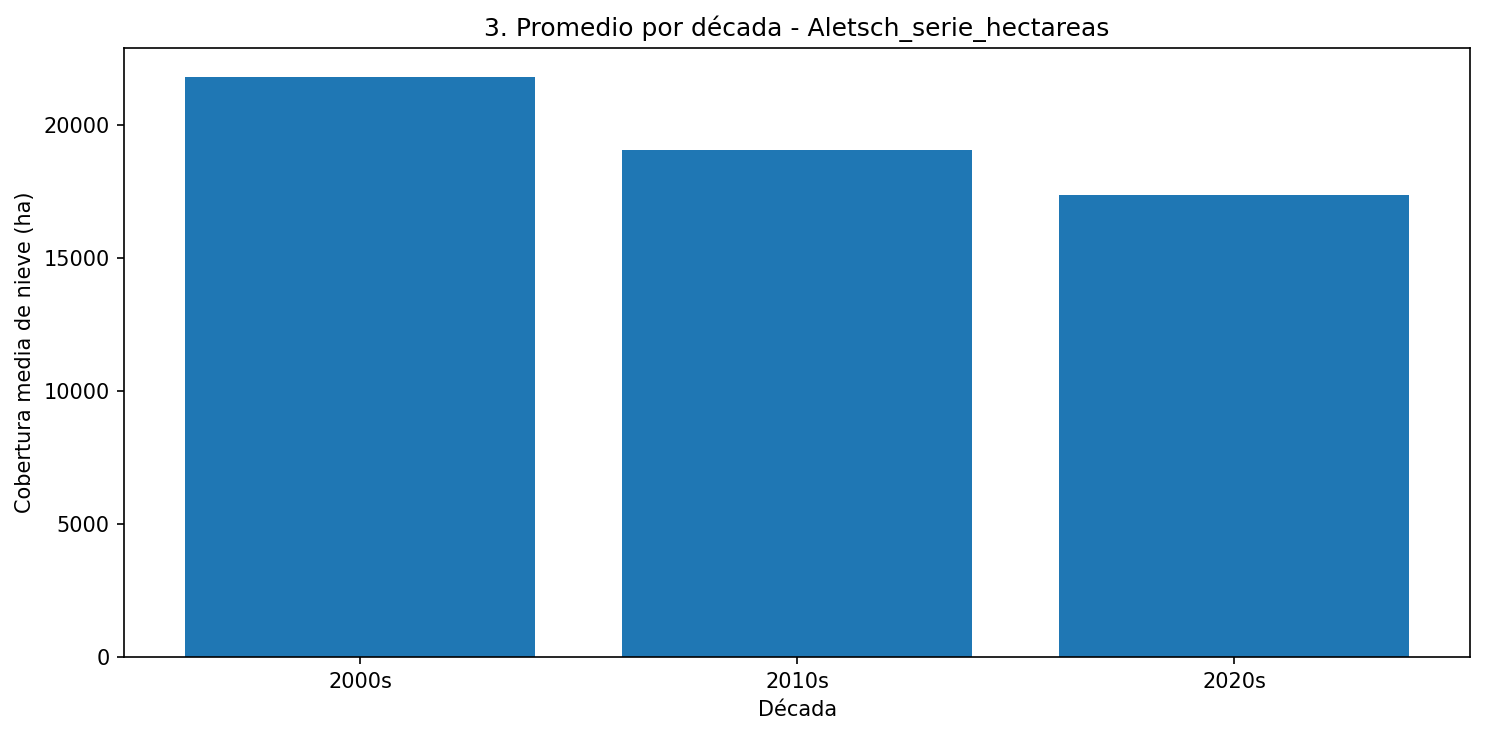

In [ ]:
decade_avg = df.groupby("decade", as_index=False)["snow_ha"].mean()
decade_avg["label"] = decade_avg["decade"].astype(str) + "s"

plt.figure()
plt.bar(decade_avg["label"], decade_avg["snow_ha"])
plt.title(f"3. Promedio por década - {SITE_NAME}")
plt.xlabel("Década")
plt.ylabel("Cobertura media de nieve (ha)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_promedio_por_decada.png", bbox_inches="tight")
plt.show()

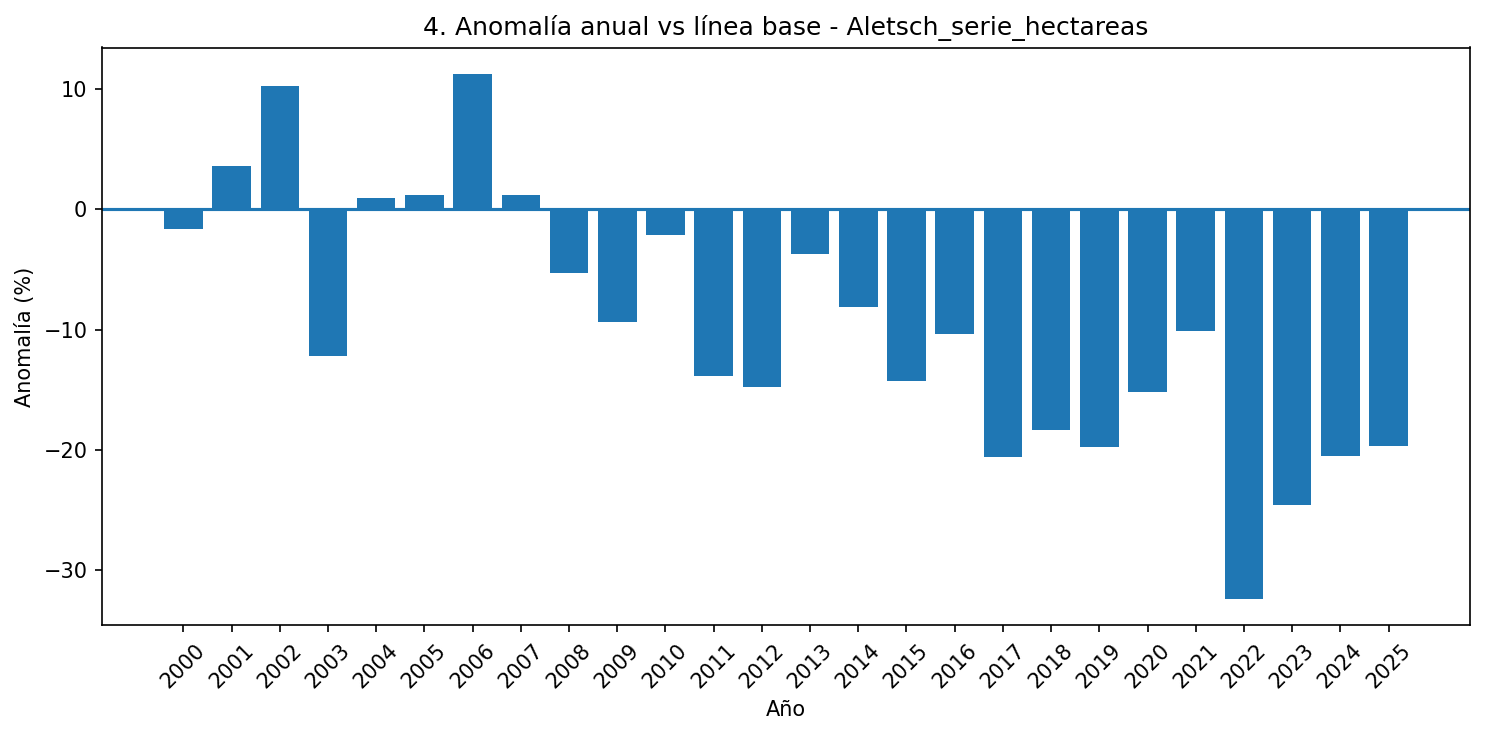

In [ ]:
plt.figure()
plt.bar(df["year"].astype(str), df["anomaly_pct"])
plt.axhline(0)
plt.title(f"4. Anomalía anual vs línea base - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Anomalía (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_anomalia_vs_linea_base.png", bbox_inches="tight")
plt.show()

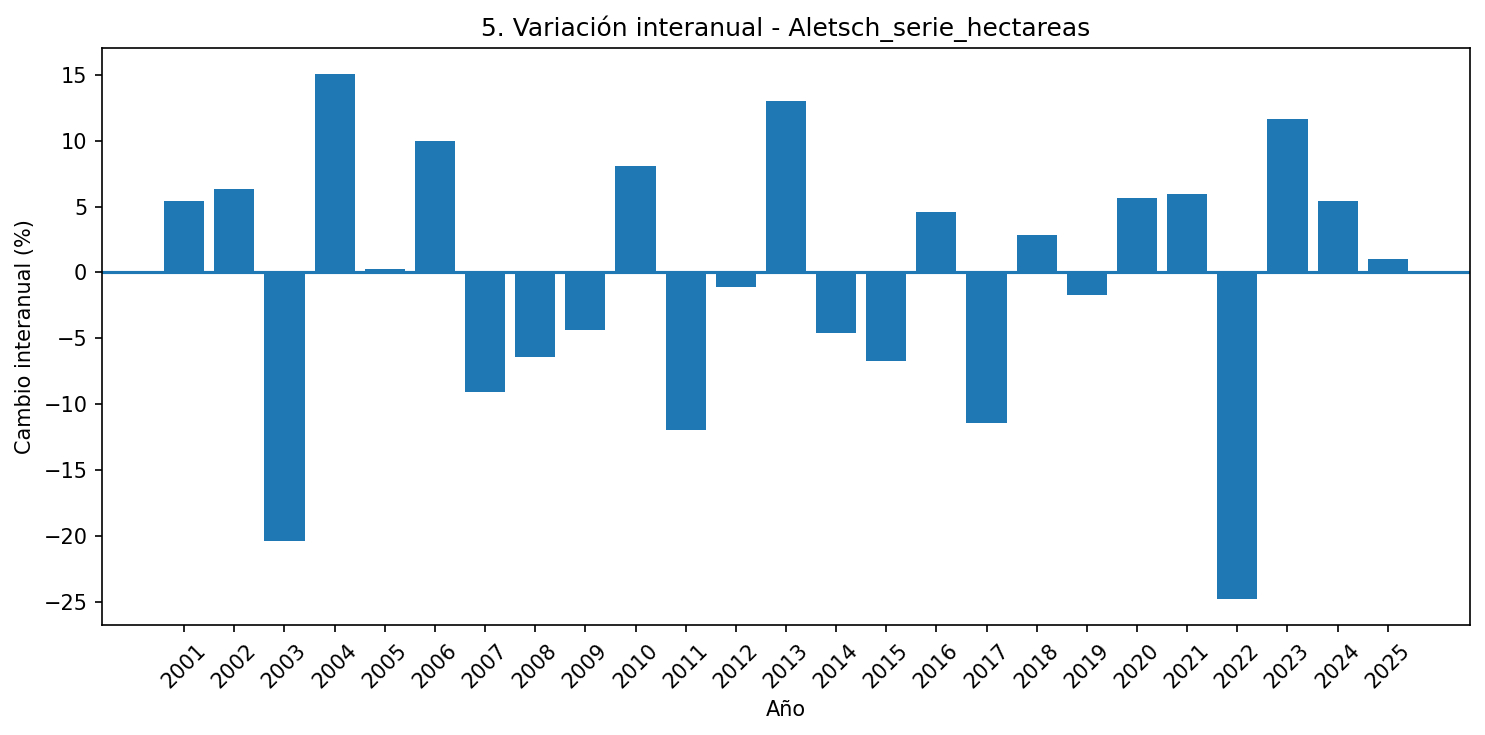

In [ ]:
plt.figure()
yoy_df = df.dropna(subset=["yoy_pct"])

plt.bar(yoy_df["year"].astype(str), yoy_df["yoy_pct"])
plt.axhline(0)
plt.title(f"5. Variación interanual - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Cambio interanual (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_variacion_interanual.png", bbox_inches="tight")
plt.show()

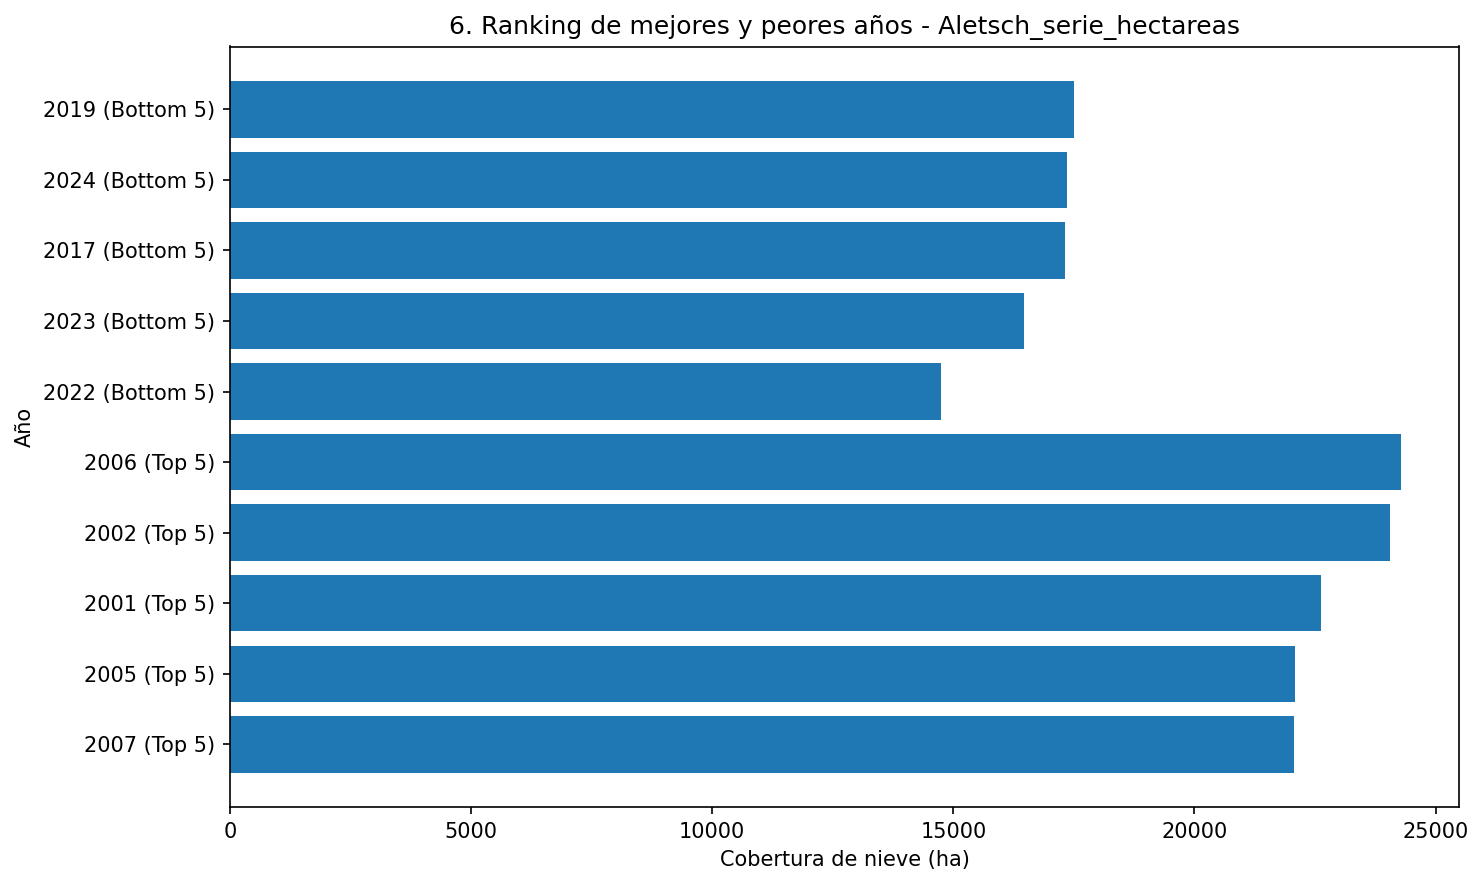

In [ ]:
rank_df = pd.concat(
    [
        top5.assign(group="Top 5"),
        bottom5.assign(group="Bottom 5")
    ],
    ignore_index=True
)

labels = [f"{int(y)} ({g})" for y, g in zip(rank_df["year"], rank_df["group"])]

plt.figure(figsize=(10, 6))
plt.barh(labels, rank_df["snow_ha"])
plt.title(f"6. Ranking de mejores y peores años - {SITE_NAME}")
plt.xlabel("Cobertura de nieve (ha)")
plt.ylabel("Año")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_ranking_top5_bottom5.png", bbox_inches="tight")
plt.show()

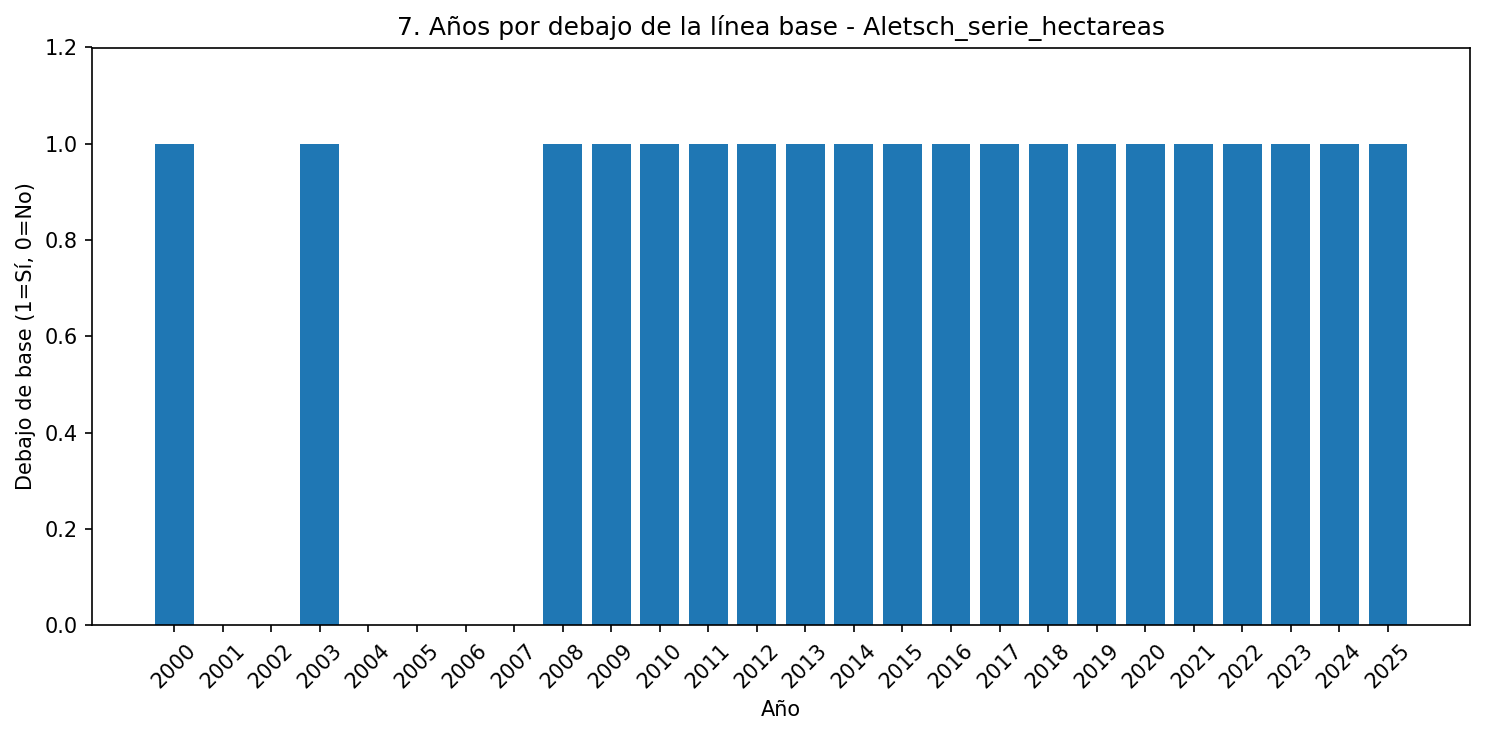

In [ ]:
plt.figure()
plt.bar(df["year"].astype(str), df["below_baseline"].astype(int))
plt.title(f"7. Años por debajo de la línea base - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Debajo de base (1=Sí, 0=No)")
plt.xticks(rotation=45)
plt.ylim(0, 1.2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_racha_bajo_linea_base.png", bbox_inches="tight")
plt.show()

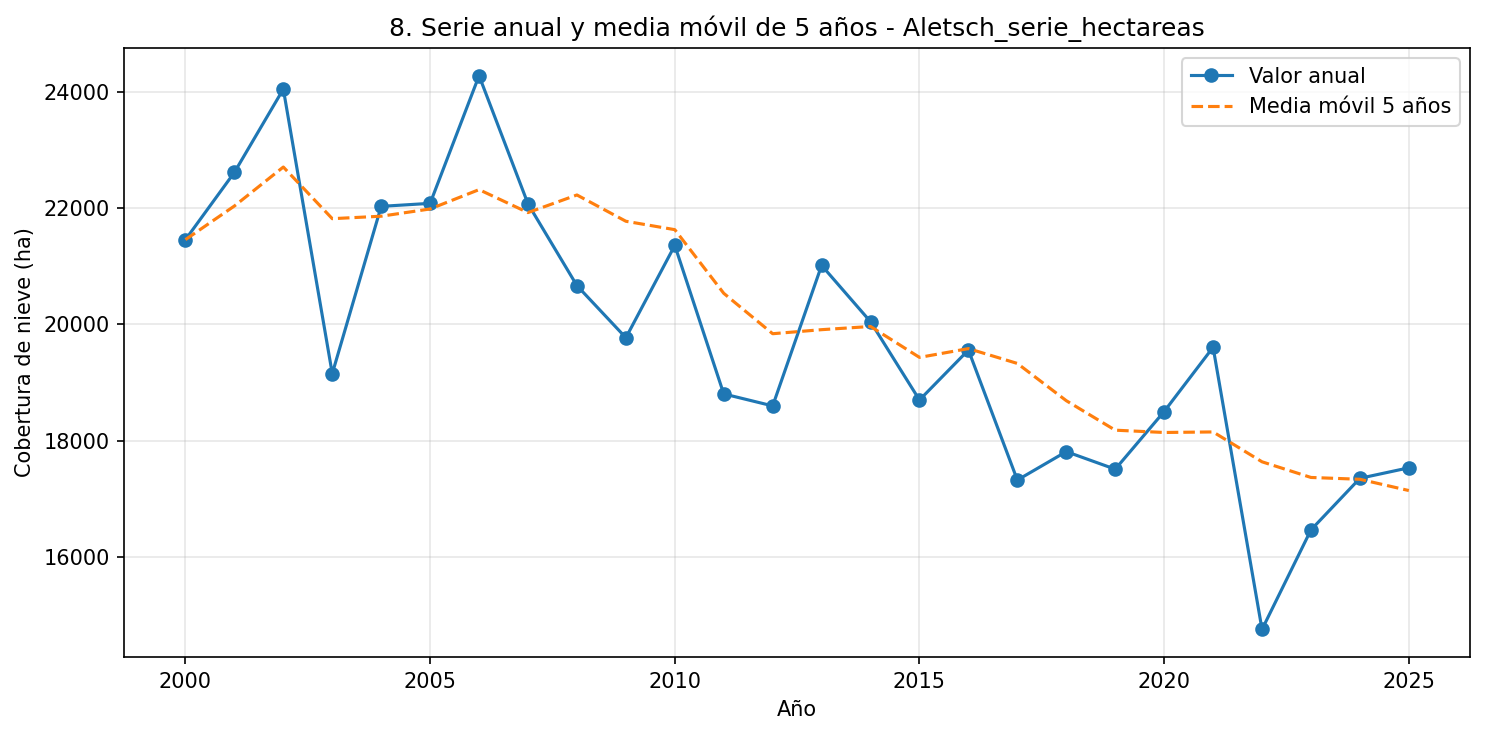

In [ ]:
plt.figure()
plt.plot(df["year"], df["snow_ha"], marker="o", label="Valor anual")
plt.plot(df["year"], df["rolling_5y"], linestyle="--", label="Media móvil 5 años")
plt.title(f"8. Serie anual y media móvil de 5 años - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Cobertura de nieve (ha)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_media_movil_5y.png", bbox_inches="tight")
plt.show()

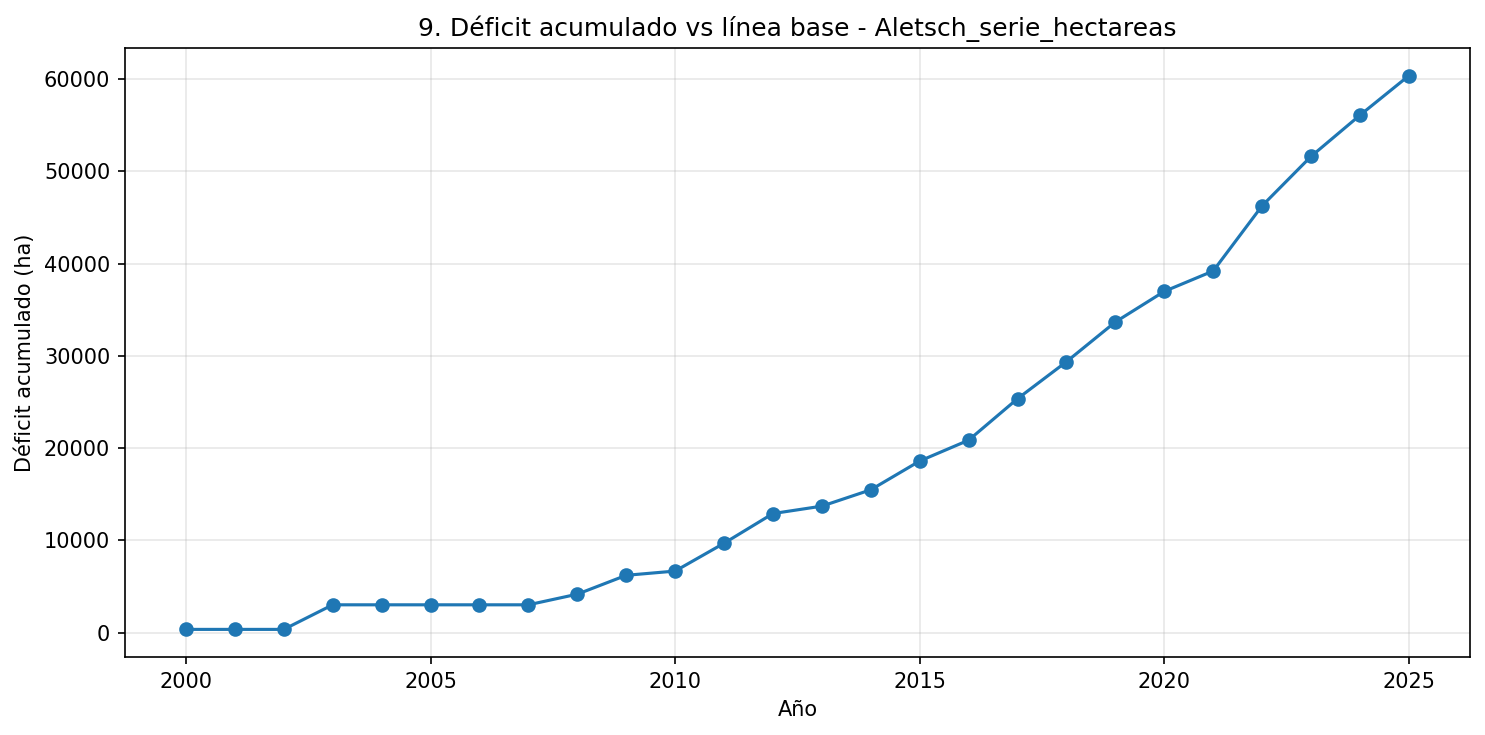

In [ ]:
plt.figure()
plt.plot(df["year"], df["cumulative_deficit_ha"], marker="o")
plt.title(f"9. Déficit acumulado vs línea base - {SITE_NAME}")
plt.xlabel("Año")
plt.ylabel("Déficit acumulado (ha)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_deficit_acumulado.png", bbox_inches="tight")
plt.show()

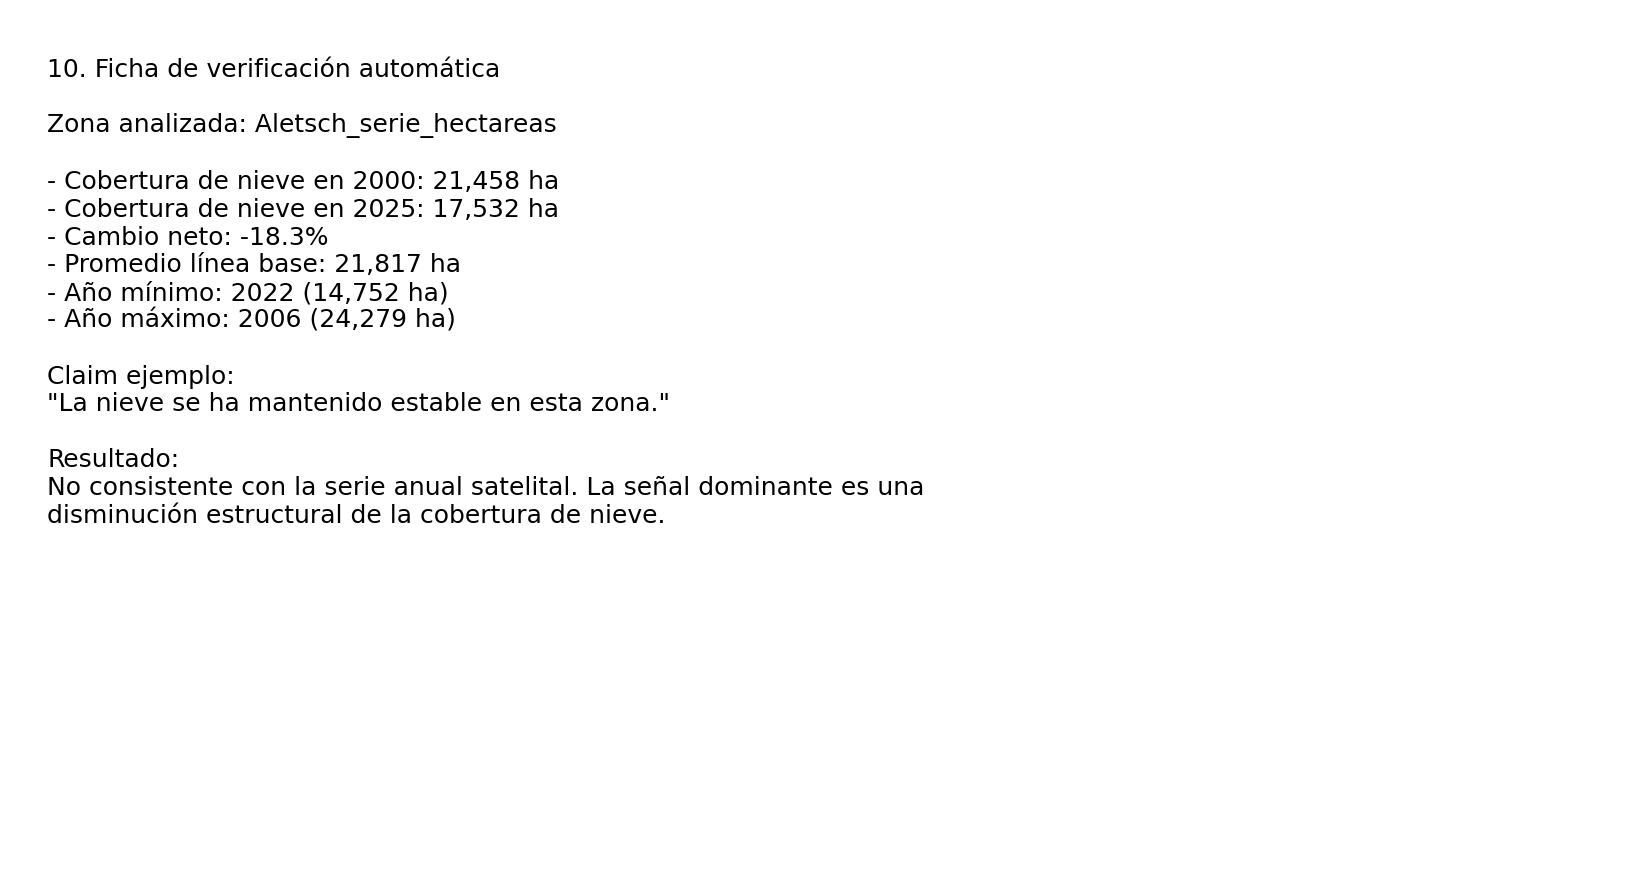

In [ ]:
plt.figure(figsize=(11, 6))
plt.axis("off")

text = (
    f"10. Ficha de verificación automática\n\n"
    f"Zona analizada: {SITE_NAME}\n\n"
    f"- Cobertura de nieve en {start_year}: {start_val:,.0f} ha\n"
    f"- Cobertura de nieve en {end_year}: {end_val:,.0f} ha\n"
    f"- Cambio neto: {net_change_pct:.1f}%\n"
    f"- Promedio línea base: {baseline_mean:,.0f} ha\n"
    f"- Año mínimo: {int(min_row['year'])} ({float(min_row['snow_ha']):,.0f} ha)\n"
    f"- Año máximo: {int(max_row['year'])} ({float(max_row['snow_ha']):,.0f} ha)\n\n"
    f'Claim ejemplo:\n"La nieve se ha mantenido estable en esta zona."\n\n'
    f"Resultado:\n"
    f"No consistente con la serie anual satelital. La señal dominante es una\n"
    f"disminución estructural de la cobertura de nieve."
)

plt.text(0.02, 0.95, text, va="top", fontsize=12)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_factcheck_card.png", bbox_inches="tight")
plt.show()